In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




In [12]:
import os
import glob
import xml.etree.ElementTree as ET

import librosa

import numpy as np

# Clasificación de cantos de aves

El dataset:

"Manually labeled Bird song dataset of 22 species from Xeno-canto to enhance deep learning acoustic classifiers with contextual information."

Jeantet Lorene1
 
Dufourq Emmanuel


Fue descargado de la pagina de Zenodo. Zenodo es un repositorio de Open Science (Ciencia Abierta) operado por el CERN (la Organización Europea para la Investigación Nuclear) en Ginebra. 

Los autores recopilan la informacion de xenocanto (otro dataset mas grande) y tomaron solo los audios de mejor calidad.
De este modo tomaron 967 audios en donde se detectan 8660 ocurrencias

Hay un archivo csv, ese archivo es el catálogo de las grabaciones de audio que los autores de descargaron de la enorme base de datos original www.xeno-canto.org.



### Exploracion del csv de Xenocanto.



--- Cantidad de grabaciones por Especie ---
Species
Troglodyte mignon              539
Troglodyte familier            512
Tarier des pr¶?s               324
Serin cini                     319
European Stonechat             261
Grive ¶? dos rouss¶tre        186
Grive ¶? bec orange            170
Grive solitaire                163
Troglodyte montagnard           99
Grive fauve                     89
Troglodyte de Baird             81
Troglodyte des for¶?ts          65
Alapi de Taczanowski            61
Grive ardois¶?e                 51
Alapi carillonneur              48
Alapi de Spix                   48
Alapi ¶? sourcils jaunes        36
Tarier p¶tre                   35
Grive de Sclater                34
Grive de Bicknell               31
Grive ¶? joues grises           31
Tarier gris                     27
Troglodyte ¶? sourcils roux     24
Grive ¶? t¶?te noire            23
Serin des Canaries              21
Serin du Cap                    18
Grive ¶? bec noir               17
Tar

C:\Users\nahue\AppData\Local\Temp\ipykernel_27004\3675243438.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Species', order=df['Species'].value_counts().index, palette='viridis')
c:\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 159 (\x9f) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


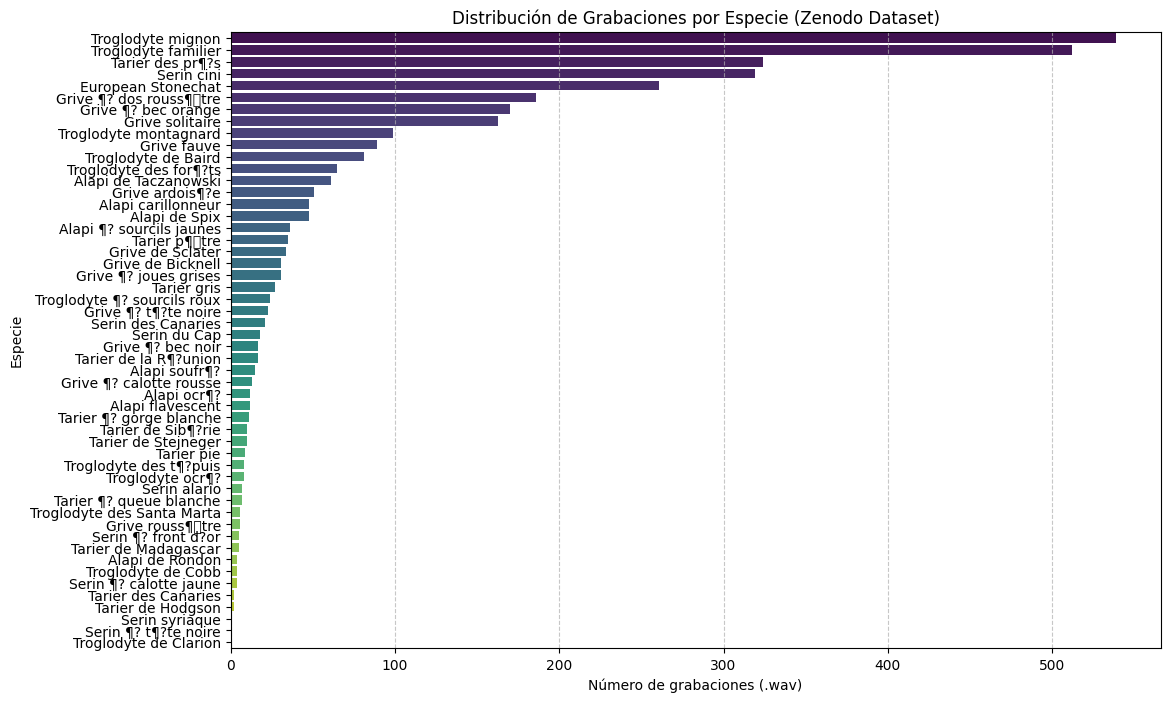

In [8]:
# Cargamos el CSV (ajustá el nombre si es necesario)
df = pd.read_csv('Xenocanto_metadata_qualityA_selection.csv', sep=';')

# 1. Resumen rápido por Especie
conteo_especies = df['Species'].value_counts()
print("--- Cantidad de grabaciones por Especie ---")
print(conteo_especies)

# 2. Resumen por Familia (útil para ver la jerarquía taxonómica)
conteo_familias = df['family'].value_counts()
print("\n--- Cantidad de grabaciones por Familia ---")
print(conteo_familias)

# 3. Visualización para tu informe (Gráfico de barras)
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='Species', order=df['Species'].value_counts().index, palette='viridis')
plt.title('Distribución de Grabaciones por Especie (Zenodo Dataset)')
plt.xlabel('Número de grabaciones (.wav)')
plt.ylabel('Especie')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [9]:
# Contamos cuántos ARCHIVOS ÚNICOS hay por especie
balanceo_archivos = df.groupby('Species')['file-name'].nunique().sort_values(ascending=False)
print(balanceo_archivos)

Species
Troglodyte mignon              539
Troglodyte familier            512
Tarier des pr¶?s               324
Serin cini                     319
European Stonechat             261
Grive ¶? dos rouss¶tre        186
Grive ¶? bec orange            170
Grive solitaire                163
Troglodyte montagnard           99
Grive fauve                     89
Troglodyte de Baird             81
Troglodyte des for¶?ts          65
Alapi de Taczanowski            61
Grive ardois¶?e                 51
Alapi de Spix                   48
Alapi carillonneur              48
Alapi ¶? sourcils jaunes        36
Tarier p¶tre                   35
Grive de Sclater                34
Grive ¶? joues grises           31
Grive de Bicknell               31
Tarier gris                     27
Troglodyte ¶? sourcils roux     24
Grive ¶? t¶?te noire            23
Serin des Canaries              21
Serin du Cap                    18
Grive ¶? bec noir               17
Tarier de la R¶?union           17
Alapi soufr¶

In [10]:
len(df)

3500

In [11]:
df

,id,gen,sp,ssp,en,rec,cnt,loc,lat,lng,...,date,Scientifique_name,Species,Number_recording,Nb_with_others,Nb_with_loc,Nb_with_cnt,order,family,genus
0,612241,Hypocnemis,cantator,NaN,Guianan Warbling Antbird,Fabrice Schmitt,Guyana,Guianan-Cock-of-the-Rock Lek Trail,4.188800,-58.989000,...,01/02/2015,Hypocnemis cantator,Alapi carillonneur,48.0,54.0,46.0,48.0,Passeriformes,Thamnophilidae,Hypocnemis
1,600092,Hypocnemis,cantator,NaN,Guianan Warbling Antbird,Felipe Arantes,Brazil,"Saracá Taquera National Forest, State of Pará",-1.660000,-56.603000,...,22/10/2020,Hypocnemis cantator,Alapi carillonneur,48.0,54.0,46.0,48.0,Passeriformes,Thamnophilidae,Hypocnemis
2,525570,Hypocnemis,cantator,NaN,Guianan Warbling Antbird,Mauricio Álvarez-Rebolledo (Colección de Sonid...,Colombia,"PNN Chiribiquete, cunaré- Amú",0.213056,-72.423611,...,02/01/2001,Hypocnemis cantator,Alapi carillonneur,48.0,54.0,46.0,48.0,Passeriformes,Thamnophilidae,Hypocnemis
3,525372,Hypocnemis,cantator,NaN,Guianan Warbling Antbird,Mauricio Álvarez-Rebolledo (Colección de Sonid...,Colombia,"PNN Chiribiquete, cunaré- Amú",0.211944,-72.417500,...,02/01/2001,Hypocnemis cantator,Alapi carillonneur,48.0,54.0,46.0,48.0,Passeriformes,Thamnophilidae,Hypocnemis
4,520034,Hypocnemis,cantator,NaN,Guianan Warbling Antbird,Rolf A. de By,Suriname,"access rd to Brownsweg summit and HQ, Brokopon...",4.953900,-55.182200,...,06/08/2019,Hypocnemis cantator,Alapi carillonneur,48.0,54.0,46.0,48.0,Passeriformes,Thamnophilidae,Hypocnemis
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495,66272,Troglodytes,rufulus,NaN,Tepui Wren,Alexandre Renaudier,Venezuela,"cerro roraima base camp, Bolivar",NaN,NaN,...,22/11/2010,Troglodytes rufulus,Troglodyte des t¶?puis,8.0,0.0,5.0,8.0,Passeriformes,Troglodytidae,Troglodytes
3496,66271,Troglodytes,rufulus,NaN,Tepui Wren,Alexandre Renaudier,Venezuela,"cerro roraima base camp, Bolivar",NaN,NaN,...,22/11/2010,Troglodytes rufulus,Troglodyte des t¶?puis,8.0,0.0,5.0,8.0,Passeriformes,Troglodytidae,Troglodytes
3497,22130,Troglodytes,rufulus,rufulus,Tepui Wren,Andrew Spencer,Venezuela,"Cerro Roraima, Bolivar",5.195900,-60.745900,...,04/07/2008,Troglodytes rufulus,Troglodyte des t¶?puis,8.0,0.0,5.0,8.0,Passeriformes,Troglodytidae,Troglodytes
3498,22129,Troglodytes,rufulus,rufulus,Tepui Wren,Andrew Spencer,Venezuela,"Cerro Roraima, Bolivar",5.195900,-60.745900,...,04/07/2008,Troglodytes rufulus,Troglodyte des t¶?puis,8.0,0.0,5.0,8.0,Passeriformes,Troglodytidae,Troglodytes


                             Cantidad_Filas  Porcentaje_%
Species                                                  
Troglodyte mignon                       539     15.430862
Troglodyte familier                     512     14.657887
Tarier des pr¶?s                        324      9.275694
Serin cini                              319      9.132551
European Stonechat                      261      7.472087
Grive ¶? dos rouss¶tre                 186      5.324936
Grive ¶? bec orange                     170      4.866877
Grive solitaire                         163      4.666476
Troglodyte montagnard                    99      2.834240
Grive fauve                              89      2.547953
Troglodyte de Baird                      81      2.318924
Troglodyte des for¶?ts                   65      1.860865
Alapi de Taczanowski                     61      1.746350
Grive ardois¶?e                          51      1.460063
Alapi carillonneur                       48      1.374177
Alapi de Spix 

<Axes: title={'center': 'Distribución por Especie'}, xlabel='Species'>

c:\Python312\Lib\site-packages\IPython\core\events.py:89: UserWarning: Glyph 159 (\x9f) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 159 (\x9f) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


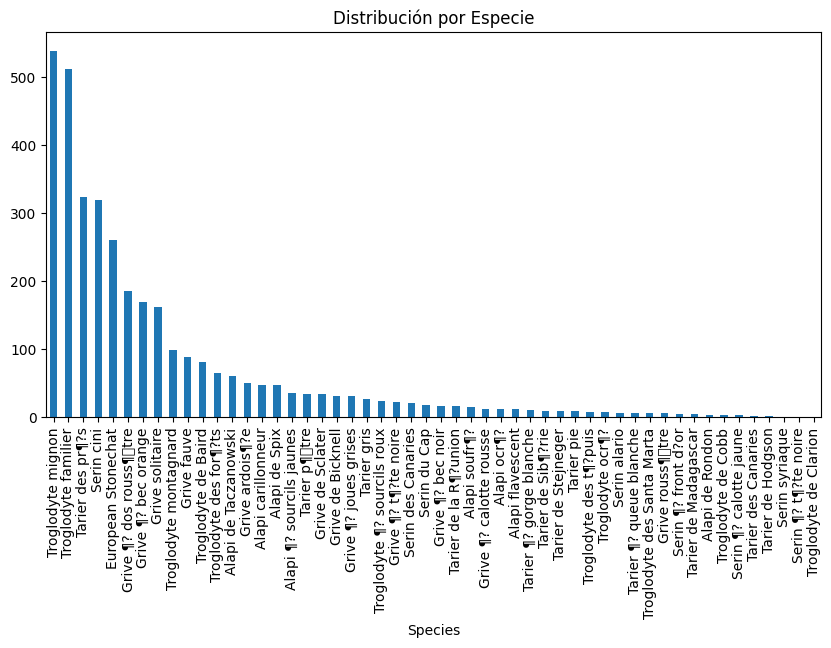

In [12]:
# 1. Conteo absoluto por especie
balance_especies = df['Species'].value_counts()

# 2. Porcentaje del total (para ver el sesgo)
porcentaje_especies = df['Species'].value_counts(normalize=True) * 100

# 3. Combinar en una tabla para ver claro
df_balance = pd.DataFrame({
    'Cantidad_Filas': balance_especies,
    'Porcentaje_%': porcentaje_especies
})

print(df_balance)

# 4. Visualización rápida
df_balance['Cantidad_Filas'].plot(kind='bar', figsize=(10,5), title='Distribución por Especie')


In [14]:
df.columns

Index(['id', 'gen', 'sp', 'ssp', 'en', 'rec', 'cnt', 'loc', 'lat', 'lng',
       'alt', 'type', 'url', 'file', 'file-name', 'time', 'date',
       'Scientifique_name', 'Species', 'Number_recording', 'Nb_with_others',
       'Nb_with_loc', 'Nb_with_cnt', 'order', 'family', 'genus'],
      dtype='object')

In [15]:
# Filtro 1: Solo las especies con suficiente representatividad
# (Dijiste que a partir de la 15 caen por debajo del 1%, vamos a ser estrictos)
top_especies = df['Species'].value_counts().head(22).index
df_final = df[df['Species'].isin(top_especies)].copy()

# Filtro 2: Asegurate de que el 'type' sea 'song' (como dice el paper)
# A veces el CSV tiene 'song', 'call', 'alarm'. Solo queremos cantos.
df_final = df_final[df_final['type'].str.contains('song', case=False, na=False)]

print(f"Filas resultantes: {len(df_final)}")
print(f"Especies seleccionadas: {df_final['Species'].nunique()}")

Filas resultantes: 2244
Especies seleccionadas: 22


In [16]:
df

,id,gen,sp,ssp,en,rec,cnt,loc,lat,lng,...,date,Scientifique_name,Species,Number_recording,Nb_with_others,Nb_with_loc,Nb_with_cnt,order,family,genus
0,612241,Hypocnemis,cantator,NaN,Guianan Warbling Antbird,Fabrice Schmitt,Guyana,Guianan-Cock-of-the-Rock Lek Trail,4.188800,-58.989000,...,01/02/2015,Hypocnemis cantator,Alapi carillonneur,48.0,54.0,46.0,48.0,Passeriformes,Thamnophilidae,Hypocnemis
1,600092,Hypocnemis,cantator,NaN,Guianan Warbling Antbird,Felipe Arantes,Brazil,"Saracá Taquera National Forest, State of Pará",-1.660000,-56.603000,...,22/10/2020,Hypocnemis cantator,Alapi carillonneur,48.0,54.0,46.0,48.0,Passeriformes,Thamnophilidae,Hypocnemis
2,525570,Hypocnemis,cantator,NaN,Guianan Warbling Antbird,Mauricio Álvarez-Rebolledo (Colección de Sonid...,Colombia,"PNN Chiribiquete, cunaré- Amú",0.213056,-72.423611,...,02/01/2001,Hypocnemis cantator,Alapi carillonneur,48.0,54.0,46.0,48.0,Passeriformes,Thamnophilidae,Hypocnemis
3,525372,Hypocnemis,cantator,NaN,Guianan Warbling Antbird,Mauricio Álvarez-Rebolledo (Colección de Sonid...,Colombia,"PNN Chiribiquete, cunaré- Amú",0.211944,-72.417500,...,02/01/2001,Hypocnemis cantator,Alapi carillonneur,48.0,54.0,46.0,48.0,Passeriformes,Thamnophilidae,Hypocnemis
4,520034,Hypocnemis,cantator,NaN,Guianan Warbling Antbird,Rolf A. de By,Suriname,"access rd to Brownsweg summit and HQ, Brokopon...",4.953900,-55.182200,...,06/08/2019,Hypocnemis cantator,Alapi carillonneur,48.0,54.0,46.0,48.0,Passeriformes,Thamnophilidae,Hypocnemis
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495,66272,Troglodytes,rufulus,NaN,Tepui Wren,Alexandre Renaudier,Venezuela,"cerro roraima base camp, Bolivar",NaN,NaN,...,22/11/2010,Troglodytes rufulus,Troglodyte des t¶?puis,8.0,0.0,5.0,8.0,Passeriformes,Troglodytidae,Troglodytes
3496,66271,Troglodytes,rufulus,NaN,Tepui Wren,Alexandre Renaudier,Venezuela,"cerro roraima base camp, Bolivar",NaN,NaN,...,22/11/2010,Troglodytes rufulus,Troglodyte des t¶?puis,8.0,0.0,5.0,8.0,Passeriformes,Troglodytidae,Troglodytes
3497,22130,Troglodytes,rufulus,rufulus,Tepui Wren,Andrew Spencer,Venezuela,"Cerro Roraima, Bolivar",5.195900,-60.745900,...,04/07/2008,Troglodytes rufulus,Troglodyte des t¶?puis,8.0,0.0,5.0,8.0,Passeriformes,Troglodytidae,Troglodytes
3498,22129,Troglodytes,rufulus,rufulus,Tepui Wren,Andrew Spencer,Venezuela,"Cerro Roraima, Bolivar",5.195900,-60.745900,...,04/07/2008,Troglodytes rufulus,Troglodyte des t¶?puis,8.0,0.0,5.0,8.0,Passeriformes,Troglodytidae,Troglodytes


Análisis de los archivos de Annotation

In [17]:
import os
import glob
import xml.etree.ElementTree as ET
from collections import defaultdict

annotation_dir = "c:/Users/nahue/Documents/Ceia/VPC2/Trabajo_beta/Annotation"
svl_files = glob.glob(os.path.join(annotation_dir, "**/*.svl"), recursive=True)

species_files = defaultdict(int)
species_occurrences = defaultdict(int)

for file in svl_files:
    # Filename format: Family_genus_species_country of recording_date_ID_song.svl
    # So we can extract genus and species from the file name, or from the folder if there are any, or just from the label tag
    filename = os.path.basename(file)
    parts = filename.split('_')
    if len(parts) >= 3:
        species_name = parts[1] + " " + parts[2]
    else:
        species_name = "Unknown"
        
    species_files[species_name] += 1
    
    # Parse XML to count occurrences
    try:
        tree = ET.parse(file)
        root = tree.getroot()
        # Find all point elements in the dataset
        points = root.findall(".//point")
        species_occurrences[species_name] += len(points)
    except Exception as e:
        print(f"Error parsing {file}: {e}")

print("Especie | Grabaciones | Ocurrencias")
print("-" * 50)
for sp in sorted(species_files.keys()):
    print(f"{sp:30} | {species_files[sp]:5} | {species_occurrences[sp]:5}")


Especie | Grabaciones | Ocurrencias
--------------------------------------------------
Catharus aurantiirostris       |    68 |   713
Catharus bicknelli             |     6 |    72
Catharus fuscater              |    29 |   416
Catharus fuscescens            |    24 |   236
Catharus guttatus              |    37 |   547
Catharus minimus               |    16 |   123
Catharus ustulatus             |    33 |   310
Hypocnemis cantator            |    32 |   167
Hypocnemis hypoxantha          |    29 |   160
Hypocnemis peruviana           |    33 |   221
Hypocnemis striata             |    11 |    55
Saxicola gutturalis            |     8 |    44
Saxicola rubetra               |    87 |  1917
Saxicola rubicola              |    70 |   636
Saxicola tectes                |    12 |    74
Saxicola torquatus             |     8 |    33
Serinus canicollis             |    14 |    71
Serinus serinus                |    83 |   633
Troglodytes aedon              |   120 |   826
Troglodytes hiemalis

In [3]:
import os
import glob
import pandas as pd
import xml.etree.ElementTree as ET

def svl_to_dataframe(svl_file_path):
    """
    Función base: Extrae la información de un solo archivo y la devuelve como una lista de diccionarios.
    Además, guarda de qué archivo y de qué subcarpeta (Training o Validation) provino la ocurrencia.
    """
    tree = ET.parse(svl_file_path)
    root = tree.getroot()
    
    # Extraer el SampleRate
    model_tag = root.find('.//model')
    sample_rate = float(model_tag.get('sampleRate', 44100)) if model_tag is not None else 44100.0
    
    # Extraer información de origen del archivo
    nombre_archivo = os.path.basename(svl_file_path)
    carpeta_origen = os.path.basename(os.path.dirname(svl_file_path)) # Sabremos si es 'Training' o 'Validation'
    
    data = []
    
    for point in root.findall('.//point'):
        frame = float(point.get('frame', 0))
        duration = float(point.get('duration', 0))
        freq_min = float(point.get('value', 0))
        freq_extent = float(point.get('extent', 0))
        label = point.get('label', 'Desconocido')
        
        start_time_sec = frame / sample_rate
        duration_sec = duration / sample_rate
        end_time_sec = start_time_sec + duration_sec
        freq_max = freq_min + freq_extent
        
        # Agregamos los datos de ocurrencia + metadata de archivo a la lista
        data.append({
            'nombre_archivo': nombre_archivo,
            'carpeta': carpeta_origen,
            'especie_label': label,
            'frecuencia_min_hz': freq_min,
            'frecuencia_max_hz': freq_max,
            'tiempo_inicio_sec': start_time_sec,
            'tiempo_fin_sec': end_time_sec,
            'duracion_sec': duration_sec
        })
        
    return data

# =========================================================================
# PASO 2: BUSCAR TODOS LOS ARCHIVOS Y CREAR EL GRAN DATAFRAME MAESTRO
# =========================================================================

# 1. Definir la ruta a tu carpeta global de anotaciones
# Usa comillas simples o dobles. Según exploré en tu directorio de trabajo, esta es la ruta:
ruta_base = "Annotation"

# 2. Utilizar glob para encontrar TODOS los archivos .svl de forma recursiva
# **/*.svl buscará tanto dentro de 'Training' como de 'Validation'
svl_files = glob.glob(os.path.join(ruta_base, "**/*.svl"), recursive=True)

print(f"Buscando... ¡Se han encontrado {len(svl_files)} archivos de grabaciones (archivos .svl)!")

# 3. Lista maestra que acumulará TODAS las ocurrencias de todos los archivos
todas_las_ocurrencias = []

for archivo in svl_files:
    try:
        # Llamar a la función para cada archivo y extraer sus ocurrencias
        ocurrencias_de_este_archivo = svl_to_dataframe(archivo)
        # Extender la lista maestra con estas nuevas ocurrencias
        todas_las_ocurrencias.extend(ocurrencias_de_este_archivo)
    except Exception as error:
        print(f"Hubo un pequeño error procesando {archivo}: {error}")

# 4. Crear finalmente el SUPER DataFrame maestro fusionado
df_master = pd.DataFrame(todas_las_ocurrencias)

print(f"¡Éxito! El DataFrame maestro contiene {len(df_master)} ocurrencias individuales de canto de aves.")

# Mostrar visualmente las primeras filas
display(df_master.head())



Buscando... ¡Se han encontrado 967 archivos de grabaciones (archivos .svl)!
¡Éxito! El DataFrame maestro contiene 8660 ocurrencias individuales de canto de aves.


,nombre_archivo,carpeta,especie_label,frecuencia_min_hz,frecuencia_max_hz,tiempo_inicio_sec,tiempo_fin_sec,duracion_sec
0,Fringillidae_Serinus_canicollis_South Africa_2...,Training,"Fringillidae_Serinus_canicollis,9",1913.66,9157.61,0.000000,3.599093,3.599093
1,Fringillidae_Serinus_canicollis_South Africa_2...,Training,"Fringillidae_Serinus_canicollis,9",1895.32,9010.90,4.133152,7.685805,3.552653
2,Fringillidae_Serinus_canicollis_South Africa_2...,Training,"Fringillidae_Serinus_canicollis,9",1601.89,8955.87,10.216780,14.373152,4.156372
3,Fringillidae_Serinus_canicollis_South Africa_2...,Training,"Fringillidae_Serinus_canicollis,9",1638.57,8974.21,15.418050,19.110023,3.691973
4,Fringillidae_Serinus_canicollis_South Africa_2...,Training,"Fringillidae_Serinus_canicollis,9",1491.86,9084.25,20.363900,23.521814,3.157914


In [5]:
df_master.to_pickle('df_master.pkl')

In [6]:
df_master = pd.read_pickle('df_master.pkl')

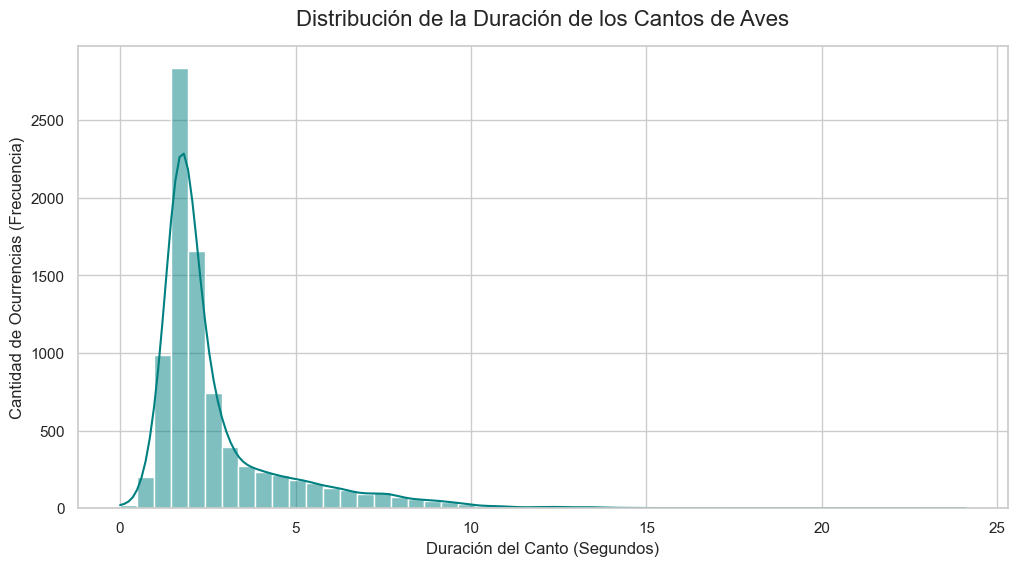

--- Resumen Estadístico de las Duraciones (en segundos) ---
count    8660.000000
mean        2.727584
std         1.952083
min         0.000021
25%         1.625397
50%         1.984000
75%         2.925714
max        24.096508
Name: duracion_sec, dtype: float64


In [7]:


# Configurar el estilo visual para que se vea profesional
sns.set_theme(style="whitegrid")

# Crear la figura (lienzo) con un tamaño fácil de leer
plt.figure(figsize=(12, 6))

# Graficar el histograma de la columna 'duracion_sec'
# bins=50 agrupa los datos en 50 barras; kde=True dibuja la curva de tendencia
sns.histplot(data=df_master, x='duracion_sec', bins=50, kde=True, color='teal')

# Agregar títulos y etiquetas a los ejes para entender el gráfico
plt.title('Distribución de la Duración de los Cantos de Aves', fontsize=16, pad=15)
plt.xlabel('Duración del Canto (Segundos)', fontsize=12)
plt.ylabel('Cantidad de Ocurrencias (Frecuencia)', fontsize=12)

# Mostrar el gráfico en el notebook
plt.show()

# Imprimir además los números exactos de la estadística descriptiva
print("--- Resumen Estadístico de las Duraciones (en segundos) ---")
print(df_master['duracion_sec'].describe())


In [8]:
df_train = df_master[df_master['carpeta'] == 'Training']
df_val = df_master[df_master['carpeta'] == 'Validation']

In [10]:
# Contar ocurrencias por especie solo en la carpeta de Training
conteos_train = df_train['especie_label'].value_counts()


In [11]:
# Quedarnos solo con el nombre de las especies que tengan >= 100 ocurrencias en Train
especies_robustas = conteos_train[conteos_train >= 100].index
# Filtrar nuestros DataFrames para borrar a las especies con pocos datos
df_train_robusto = df_train[df_train['especie_label'].isin(especies_robustas)]
df_val_robusto = df_val[df_val['especie_label'].isin(especies_robustas)]
print(f"Especies seleccionadas para entrenamiento ({len(especies_robustas)} especies):")
print(especies_robustas.tolist())

Especies seleccionadas para entrenamiento (16 especies):
['Paridae_Saxicola_rubetra,9', 'Troglodytidae_Troglodytes_aedon,9', 'Turdidae_Catharus_guttatus,9', 'Turdidae_Catharus_aurantiirostris,8', 'Troglodytidae_Troglodytes_troglodytes, 10', 'Troglodytidae_Troglodytes_troglodytes,9', 'Fringillidae_Serinus_serinus,9', 'Paridae_Saxicola_rubicola,9', 'Turdidae_Catharus_fuscater,9', 'Paridae_Saxicola_rubetra,8', 'Turdidae_Catharus_aurantiirostris,9', 'Troglodytidae_Troglodytes_hiemalis,9', 'Turdidae_Catharus_ustulatus,9', 'Paridae_Saxicola_rubicola,8', 'aridae_Saxicola_rubetra,9', 'Troglodytidae_Troglodytes_pacificus,9']


In [25]:
tiempo_ideal = df_train_robusto['duracion_sec'].quantile(0.90)
print(f"El 90% de los cantos dura {tiempo_ideal:.2f} segundos o menos.")


El 90% de los cantos dura 5.82 segundos o menos.


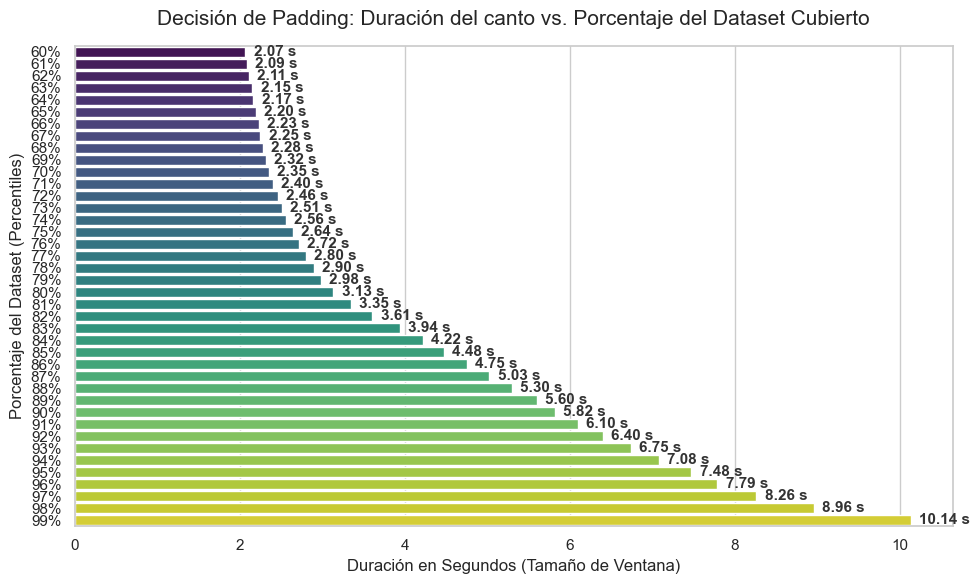

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir los porcentajes (cuantiles) que queremos ver: del 60% al 100% saltando de a 5%
percentiles = np.arange(0.60, 1, 0.01)

# 2. Calcular los valores de duración exacta en segundos para cada percentil
duraciones = df_train_robusto['duracion_sec'].quantile(percentiles)

# 3. Crear etiquetas legibles para el eje Y (ej: "60%", "65%")
etiquetas_y = [f"{int(p * 100)}%" for p in percentiles]

# 4. Configurar el gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Dibujar el gráfico de barras horizontales
sns.barplot(x=duraciones.values, y=etiquetas_y, hue=etiquetas_y, palette="viridis", legend=False)

# Añadir títulos y etiquetas a los ejes
plt.title('Decisión de Padding: Duración del canto vs. Porcentaje del Dataset Cubierto', fontsize=15, pad=15)
plt.xlabel('Duración en Segundos (Tamaño de Ventana)', fontsize=12)
plt.ylabel('Porcentaje del Dataset (Percentiles)', fontsize=12)

# 5. Escribir el número exacto (con 2 decimales) flotando al final de cada barra
for indice, valor in enumerate(duraciones.values):
    plt.text(valor + 0.1, indice, f"{valor:.2f} s", va='center', fontsize=11, fontweight='bold', color='#333333')

# Ajustar los márgenes automáticamente y mostrar
plt.tight_layout()
plt.show()


In [ ]:


def extraer_canto_exacto(ruta_audio, tiempo_inicio_sec, duracion_sec):
    """
    Paso 1: Carga y recorta una señal de audio basándose en la etiqueta de tiempo exacta.
    
    Parámetros:
    - ruta_audio: La ubicación exacta en tu disco duro del archivo .wav
    - tiempo_inicio_sec: El segundo exacto donde dice el XML que empieza el canto
    - duracion_sec: Cuánto dura el canto según el XML
    
    Retorna:
    - audio_recortado: Un array 1D de Numpy que contiene SÓLO la señal del canto del ave.
    - sr: El Sample Rate (Frecuencia de muestreo) con el que se cargó el audio.
    """
    
    # Validar que el archivo de audio físico exista en la carpeta
    if not os.path.exists(ruta_audio):
        print(f"Error: No pude encontrar el archivo de audio en {ruta_audio}. ¿Ya descomprimiste Audio_birds2.zip?")
        return None, None
        
    try:
        # Librosa es genial: en lugar de cargar todo el archivo pesado a la RAM, 
        # le podemos decir que cargue SÓLO el pedacito que nos interesa (offset y duration).
        # sr=None le indica a librosa que mantenga la frecuencia de muestreo original del archivo (ej. 44100 Hz).
        audio_recortado, sr = librosa.load(ruta_audio, 
                                           sr=None, 
                                           offset=tiempo_inicio_sec, 
                                           duration=duracion_sec)
        
        return audio_recortado, sr
        
    except Exception as e:
        print(f"Hubo un error al procesar el audio {ruta_audio}: {e}")
        return None, None

# ==========================================================
# CÓMO PROBAR SI ESTO FUNCIONA CON TU PRIMERA OCURRENCIA:
# ==========================================================

# 1. Tomamos la fila [0] de nuestro DataFrame maestro como conejillo de indias
primera_fila = df_master.iloc[0]

# 2. Reconstruimos la ruta donde debería estar el archivo .wav
# NOTA: Asegúrate de que el nombre de tus audios termine en .wav o .mp3 según tu carpeta.
# El nombre en el xml termina en .svl, así que le cambiamos la extensión a .wav
nombre_audio_wav = primera_fila['nombre_archivo'].replace('.svl', '.mp3')
carpeta_origen = primera_fila['carpeta'] # 'Training' o 'Validation'

# Esta es la ruta asumiendo que descomprimiste los audios en una carpeta llamada 'Audio_birds2'
ruta_al_audio = os.path.join("Audio_birds2", carpeta_origen, nombre_audio_wav)

print(f"Voy a intentar recortar el archivo: {ruta_al_audio}")
print(f"Buscando desde el segundo {primera_fila['tiempo_inicio_sec']:.2f} hasta el {primera_fila['tiempo_fin_sec']:.2f}...")

# 3. Mandamos a llamar a nuestra función ingenieril
canto_aislado, sample_rate = extraer_canto_exacto(ruta_al_audio, 
                                                  primera_fila['tiempo_inicio_sec'], 
                                                  primera_fila['duracion_sec'])

if canto_aislado is not None:
    print(f"¡Éxito! Se ha recortado la señal acústica.")
    print(f"Tenemos un array unidimensional de tamaño: {canto_aislado.shape}")
    print(f"Que equivale a {len(canto_aislado) / sample_rate:.2f} segundos de audio puro de pájaro.")


Voy a intentar recortar el archivo: Audio_birds2\Training\Fringillidae_Serinus_canicollis_South Africa_2014-10-28_XC280667_song.mp3
Buscando desde el segundo 0.00 hasta el 3.60...
¡Éxito! Se ha recortado la señal acústica.
Tenemos un array unidimensional de tamaño: (158720,)
Que equivale a 3.60 segundos de audio puro de pájaro.


In [34]:
import librosa
import numpy as np

# Definimos que TODAS nuestras ventanas de la Red Neuronal duren exactamente 6 segundos
DURACION_RED_NEURONAL_SEC = 6.0 

# Tomamos el primer archivo único que exista en nuestro DataFrame
archivo_ejemplo = df_master['nombre_archivo'].iloc[0]
carpeta_ejemplo = df_master['carpeta'].iloc[0]

# Filtramos TODAS las ocurrencias (cortes) que pertenecen puramente a este archivo
cortes_de_este_archivo = df_master[df_master['nombre_archivo'] == archivo_ejemplo]

# Ruta al mp3
ruta_mp3 = os.path.join("Audio_birds2", carpeta_ejemplo, archivo_ejemplo.replace('.svl', '.mp3'))

print(f"Cargando el enorme archivo MP3 UNA SOLA VEZ a memoria... (Tardará un par de segundos)")
# Cargamos EL ARCHIVO ENTERO (sin offset)
audio_completo_ram, sr = librosa.load(ruta_mp3, sr=None)
print("¡Archivo cargado a RAM al instante!")

muestras_totales_ventana = int(DURACION_RED_NEURONAL_SEC * sr) # Ej: 6.0 seg * 44100 = 264600 puntos
espectrogramas_audio = [] # Aquí guardaremos nuestros recortes listos para entrenar

# Ahora iteramos velozmente sobre los recortes usando el Array en RAM
print(f"Extrayendo y 'Padeando' {len(cortes_de_este_archivo)} ocurrencias al instante...")

for idx, fila in cortes_de_este_archivo.iterrows():
    # 1. Encontrar los índices matemáticos exactos en el array 1D
    muestra_inicio = int(fila['tiempo_inicio_sec'] * sr)
    muestra_fin = int((fila['tiempo_inicio_sec'] + fila['duracion_sec']) * sr)
    
    # 2. Recortar (slicing puro de Python, trada 0.00001 segundos)
    canto = audio_completo_ram[muestra_inicio:muestra_fin]
    
    # 3. PADDING INTELIGENTE (¡La idea brillante de rellenar con el entorno!)
    largo_actual = len(canto)
    
    if largo_actual < muestras_totales_ventana:
        # Nos faltan muestras para llegar a los 6 segundos.
        muestras_faltantes = muestras_totales_ventana - largo_actual
        
        # Vamos a tomar un poco del sonido "ambiente" del mismo audio original
        # Si el pájaro cantó en el segundo 10, tomaremos ruido del segundo 2 (que sabemos que está vacío)
        # Tomamos un segmento de ruido al principio del audio original 
        # (Esto es básico, idealmente deberías asegurar que no caiga otra ocurrencia ahí)
        segmento_ruido = audio_completo_ram[0 : muestras_faltantes]
        
        # Concatenamos (Padding) el Canto + el Ruido de fondo
        canto_final_paddeado = np.concatenate((canto, segmento_ruido))
        
    elif largo_actual > muestras_totales_ventana:
        # Si el canto es más largo que 6 segundos, lo truncamos (cortamos lo que sobra)
        canto_final_paddeado = canto[0:muestras_totales_ventana]
    else:
        canto_final_paddeado = canto
        
    espectrogramas_audio.append(canto_final_paddeado)

print(f"¡Listo! Se extrajeron {len(espectrogramas_audio)} fragmentos de EXACTAMENTE 6.0 segundos.")
print(f"Formato final del primer recorte de entrenamiento: {espectrogramas_audio[0].shape} puntos.")


Cargando el enorme archivo MP3 UNA SOLA VEZ a memoria... (Tardará un par de segundos)
¡Archivo cargado a RAM al instante!
Extrayendo y 'Padeando' 5 ocurrencias al instante...
¡Listo! Se extrajeron 5 fragmentos de EXACTAMENTE 6.0 segundos.
Formato final del primer recorte de entrenamiento: (264600,) puntos.


In [4]:
import os
import librosa
import numpy as np
from tqdm import tqdm  # Barra de progreso bonita para Jupyter Notebook

# Hiperparámetros de nuestra arquitectura
DURACION_RED_NEURONAL_SEC = 6.0
N_MELS = 128  # Cantidad de "píxeles" de resolución vertical (bandas de frecuencia)

# Listas maestras donde guardaremos todo en RAM
X_data = []      # Matriz 3D final con TODOS los espectrogramas
y_labels = []    # Lista con el nombre del pájaro correspondiente
carpetas = []    # Para separar Train y Test luego

# Encontrar los archivos ÚNICOS en tu base de datos robusta (ej. df_train_robusto si lo filtraste, o df_master)
# Vamos a hacerlo con df_master completo como pediste para "todos" los archivos:
archivos_unicos = df_master['nombre_archivo'].unique()

print(f"Iniciando Pipeline... Procesando {len(archivos_unicos)} archivos de audio únicos.")

# El bucle mágico con barra de progreso
for archivo in tqdm(archivos_unicos, desc="Generando Espectrogramas"):
    
    # Obtener todas las ocurrencias (cortes) que pertenecen a este mp3 en particular
    cortes = df_master[df_master['nombre_archivo'] == archivo]
    carpeta = cortes['carpeta'].iloc[0]
    
    # Reconstruir la ruta exacta
    ruta_mp3 = os.path.join("Audio_birds2", carpeta, archivo.replace('.svl', '.mp3'))
    
    if not os.path.exists(ruta_mp3):
        continue  # Si por alguna razón no existe, saltamos al siguiente
        
    try:
        # Cargar el archivo de 5 minutos a RAM UNA ÚNICA VEZ
        audio_completo, sr = librosa.load(ruta_mp3, sr=None)
        muestras_totales_ventana = int(DURACION_RED_NEURONAL_SEC * sr)
        
        # Iterar sobre las múltiples aves dentro del archivo
        for idx, fila in cortes.iterrows():
            muestra_inicio = int(fila['tiempo_inicio_sec'] * sr)
            muestra_fin = int((fila['tiempo_inicio_sec'] + fila['duracion_sec']) * sr)
            
            canto = audio_completo[muestra_inicio:muestra_fin]
            largo_actual = len(canto)
            
            # --- Lógica del Bounding Box / Padding ---
            if largo_actual < muestras_totales_ventana:
                # Extraer un segmento inicial de puro ruido ambiental para "rellenar" la diferencia
                pad_ruido = audio_completo[0 : (muestras_totales_ventana - largo_actual)]
                canto_procesado = np.concatenate((canto, pad_ruido))
            else:
                # Truncar los pájaros que cantan demasiado tiempo (> 6 seg)
                canto_procesado = canto[0:muestras_totales_ventana]
                
            # --- CONVERSIÓN A ESPECTROGRAMA ---
            # Transformada de Fourier con Escala MEL (Imita cómo oye el oído de un pájaro/humano)
            mel_spec = librosa.feature.melspectrogram(y=canto_procesado, 
                                                      sr=sr, 
                                                      n_mels=N_MELS, 
                                                      fmax=10000) # Frecuencia max que le importa a la red (hz)
            
            # Convertir intensidad a Decibelios (escala logarítmica)
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
            
            # Guardamos todo
            X_data.append(mel_spec_db)
            y_labels.append(fila['especie_label'])
            carpetas.append(carpeta)
            
    except Exception as error:
        print(f"Error silencioso en archivo {archivo}: {error}")

# --- Paso Final: Convertir a Tensores Multidimensionales para Machine Learning ---
X = np.array(X_data)      # Entradas de la red neuronal (Imágenes)
y = np.array(y_labels)    # Salidas a predecir
splits = np.array(carpetas)

print("\n¡PIPELINE TERMINADO CON ÉXITO!")
print("=================================")
print(f"Dimensiones de Matriz X (Tus {len(X)} Espectrogramas): {X.shape}")
print(f"Dimensiones del Vector y (Tus {len(y)} target labels): {y.shape}")


Iniciando Pipeline... Procesando 967 archivos de audio únicos.


c:\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generando Espectrogramas: 100%|██████████| 967/967 [05:30<00:00,  2.92it/s]


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (8637, 128) + inhomogeneous part.

In [ ]:

from collections import Counter

# 1. Analizar obsesivamente los anchos de todas nuestras imágenes
anchos = [matriz.shape[1] for matriz in X_data]

# 2. Descubrir cuál es el "Ancho Perfecto" oficial (el que más se repite, la moda)
conteo = Counter(anchos)
ancho_perfecto = conteo.most_common(1)[0][0]

print(f"El ancho esperado oficial para cada imagen es: {ancho_perfecto} columnas (frames).")
print(f"Se encontraron estas variaciones en el dataset: {conteo}")

# 3. Forzar matemáticamente (Parchar) a todos los espectrogramas a tener el mismo ancho exacto en el Eje X (axis=1)
X_corregida_lista = [librosa.util.fix_length(mat, size=ancho_perfecto, axis=1) for mat in X_data]

# 4. Ahora sí, construir el Tensor 3D sin que Numpy llore
X = np.array(X_corregida_lista)
y = np.array(y_labels)
splits = np.array(carpetas)

print(f"\n¡Tensor construido maravillosamente! Dimensiones finales de X: {X.shape}")

# AHORA SÍ: Guardar definitivamente con seguridad para el futuro
import numpy as np
np.save('X_espectrogramas.npy', X)
np.save('y_etiquetas_especies.npy', y)
np.save('splits_carpetas.npy', splits)
print("¡Matrices blindadas y guardadas exitosamente en el disco duro!")


El ancho esperado oficial para cada imagen es: 517 columnas (frames).
Se encontraron estas variaciones en el dataset: Counter({517: 5576, 563: 2920, 376: 113, 282: 15, 259: 11, 456: 1, 453: 1})

¡Tensor construido maravillosamente! Dimensiones finales de X: (8637, 128, 517)
¡Matrices blindadas y guardadas exitosamente en el disco duro!


In [ ]:

# Nombre de la carpeta maestra que le enviarás a tus compañeros
carpeta_maestra = "Dataset_Imagenes_Aves"
print("Guardando miles de espectrogramas como imágenes PNG...")
print("Esto tomará un par de minutos, ve a prepararte para salir.")
# Iteramos sobre todos nuestros datos en RAM (ej: del 0 al 8636)
for i in range(len(X)):
    
    # Extraemos el dato individual
    espectrograma_2d = X[i]
    especie_pajaro = y[i]
    conjunto = splits[i]  # "Training" o "Validation"
    
    # 1. Armar la ruta exacta de la subcarpeta (Ej: Dataset/Training/Troglodytes_aedon/)
    ruta_subcarpeta = os.path.join(carpeta_maestra, conjunto, especie_pajaro)
    
    # 2. Crear físicamente la carpeta en Windows si es que aún no existe
    os.makedirs(ruta_subcarpeta, exist_ok=True)
    
    # 3. Definir el nombre del archivo de imagen
    nombre_imagen = f"canto_{i}.png"
    ruta_guardado = os.path.join(ruta_subcarpeta, nombre_imagen)
    
    # 4. Guardar la matriz numpy como una imagen a color real
    # 'viridis' es el esquema de colores azul/amarillo estándar para espectrogramas
    # origin='lower' asegura que las frecuencias bajas queden abajo en la foto
    plt.imsave(ruta_guardado, espectrograma_2d, cmap='viridis', origin='lower')
print("\n=======================================================")
print("¡ÉXITO ABSOLUTO! Revisa tu carpeta 'Trabajo_beta'.")
print("Te encontrarás una carpeta llamada 'Dataset_Imagenes_Aves'.")
print("Hazle click derecho, envíala a un archivo ZIP y mándasela a tu equipo.")
print("=======================================================")

Exception ignored in: <function tqdm.__del__ at 0x0000016075B00C20>
Traceback (most recent call last):
  File "c:\Python312\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Python312\Lib\site-packages\tqdm\notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
Exception ignored in: <function tqdm.__del__ at 0x0000016075B00C20>
Traceback (most recent call last):
  File "c:\Python312\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Python312\Lib\site-packages\tqdm\notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


Guardando miles de espectrogramas como imágenes PNG...
Esto tomará un par de minutos, ve a prepararte para salir.

¡ÉXITO ABSOLUTO! Revisa tu carpeta 'Trabajo_beta'.
Te encontrarás una carpeta llamada 'Dataset_Imagenes_Aves'.
Hazle click derecho, envíala a un archivo ZIP y mándasela a tu equipo.
